In [8]:

import matplotlib
%matplotlib inline 
from sklearn import svm 
import tensorflow as tf
from tensorflow.keras.utils import get_file 
import os 
import gensim 
import numpy as np 
import random 
import requests 
import geopandas as gpd 
from IPython.core.pylabtools import figsize 
import csv
figsize(12, 8)

In [9]:
#下载模型
MODEL = 'GoogleNews-vectors-negative300.bin'
# path = get_file(MODEL + '.gz', 'https://s3.amazonaws.com/d l4j-distribution/%s.gz' % MODEL)
# #path = './data/' + MODEL + '.gz' 
# unzipped = os.path.join('generated', MODEL) 
# if not os.path.isfile(unzipped):
#      with open(unzipped, 'wb') as fout: 
#             zcat = subprocess.Popen(['zcat'],
#                                      stdin=open(path),
#                                      stdout=fout
#                                      ) 
#             zcat.wait()

In [10]:
#加载model
model = gensim.models.KeyedVectors.load_word2vec_format(MODEL, binary=True)

In [11]:
print("寻找相似的单词，espresso")
model.most_similar(positive=['espresso'])

寻找相似的单词，espresso


[('cappuccino', 0.6888186931610107),
 ('mocha', 0.6686208844184875),
 ('coffee', 0.6616826057434082),
 ('latte', 0.6536753177642822),
 ('caramel_macchiato', 0.6491268873214722),
 ('ristretto', 0.6485545635223389),
 ('espressos', 0.6438628435134888),
 ('macchiato', 0.6428250074386597),
 ('chai_latte', 0.6308028697967529),
 ('espresso_cappuccino', 0.6280542612075806)]

In [12]:
#A与B的关系和C与谁的关系相似


In [13]:
#可视化

In [15]:
#在词嵌入中发现实体类
countries = list(csv.DictReader(open('data/countries.csv'))) 
countries[:10]
positive = [x['name'] for x in random.sample(countries, 40)]
negative = random.sample(model.vocab.keys(), 5000) 
negative[:4]
labelled = [(p, 1) for p in positive] + [(n, 0) for n in negative] 
random.shuffle(labelled) 
X = np.asarray([model[w] for w, l in labelled]) 
y = np.asarray([l for w, l in labelled]) 
X.shape, y.shape

((5040, 300), (5040,))

In [16]:
TRAINING_FRACTION = 0.3 
cut_off = int(TRAINING_FRACTION * len(labelled)) 
clf = svm.SVC(kernel='linear')
clf.fit(X[:cut_off], y[:cut_off]) 

SVC(kernel='linear')

NameError: name 'SVC' is not defined

In [19]:
res = clf.predict(X[cut_off:])

In [20]:
missed = [country for (pred, truth, country) in  zip(res, y[cut_off:], labelled[cut_off:]) if pred != truth ]
100 - 100 * float(len(missed)) / len(res), missed

(99.82993197278911,
 [('Gaza_Strip', 1),
  ('Andrews_Air_Force', 0),
  ('Greece', 0),
  ('Kosovo', 1),
  ('Riviera_Maya', 0),
  ('Russia', 1)])

In [23]:
all_predictions = clf.predict(model.syn0)

<ipython-input-23-1f5967792fc7>:1: DeprecationWarning: Call to deprecated `syn0` (Attribute will be removed in 4.0.0, use self.vectors instead).
  all_predictions = clf.predict(model.syn0)


In [24]:
res = [] 
for word, pred in zip(model.index2word, all_predictions):    
    if pred:        
        res.append(word)        
        if len(res) == 150:            
            break 
random.sample(res, 10)

['Ireland',
 'Saudi_Arabia',
 'Kerala',
 'Norway',
 'El_Paso',
 'Hawaii',
 'Netherlands',
 'Iceland',
 'Uruguay',
 'Haiti']

In [26]:
country_to_idx = {country['name']: idx for idx, country in enumerate(countries)} 
country_vecs = np.asarray([model[c['name']] for c in countries]) 
country_vecs.shape

(184, 300)

In [34]:
dists = np.dot(country_vecs, country_vecs[country_to_idx['Germany']]) 
for idx in reversed(np.argsort(dists)[-10:]):
     print(countries[idx]['name'], dists[idx])
def rank_countries(term, topn=10, field='name'):
    if not term in model:
        return []
    vec = model[term]
    dists = np.dot(country_vecs, vec)
    return [(countries[idx][field], float(dists[idx]))
            for idx in reversed(np.argsort(dists)[-topn:])]
rank_countries('cricket')

Germany 7.0687747
Austria 5.6941714
Hungary 5.124521
Slovakia 5.0059595
Netherlands 4.9229164
Poland 4.9070873
Switzerland 4.8861256
Sweden 4.816231
Czech_Republic 4.7731876
Slovenia 4.728077


[('Sri_Lanka', 5.92276668548584),
 ('Zimbabwe', 5.336524963378906),
 ('Bangladesh', 5.192488670349121),
 ('Pakistan', 4.948408126831055),
 ('Guyana', 3.9162840843200684),
 ('Barbados', 3.757995128631592),
 ('India', 3.7504398822784424),
 ('South_Africa', 3.6561501026153564),
 ('New_Zealand', 3.64202880859375),
 ('Fiji', 3.608567714691162)]

In [35]:
world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres')) 
world.head()

,pop_est,continent,name,iso_a3,gdp_md_est,geometry
0,920938,Oceania,Fiji,FJI,8374.0,"MULTIPOLYGON (((180.00000 -16.06713, 180.00000..."
1,53950935,Africa,Tanzania,TZA,150600.0,"POLYGON ((33.90371 -0.95000, 34.07262 -1.05982..."
2,603253,Africa,W. Sahara,ESH,906.5,"POLYGON ((-8.66559 27.65643, -8.66512 27.58948..."
3,35623680,North America,Canada,CAN,1674000.0,"MULTIPOLYGON (((-122.84000 49.00000, -122.9742..."
4,326625791,North America,United States of America,USA,18560000.0,"MULTIPOLYGON (((-122.84000 49.00000, -120.0000..."


In [36]:
def map_term(term):
    d = {k.upper(): v for k, v in rank_countries(term, topn =0, field='cc3')}
    world[term] = world['iso_a3'].map(d)
    world[term] /= world[term].max()
    world.dropna().plot(term, cmap='OrRd')

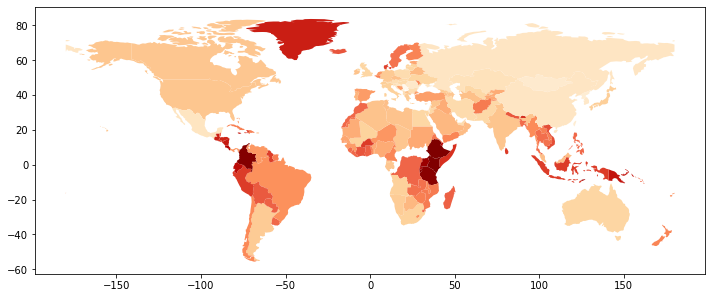

In [37]:
map_term('coffee')

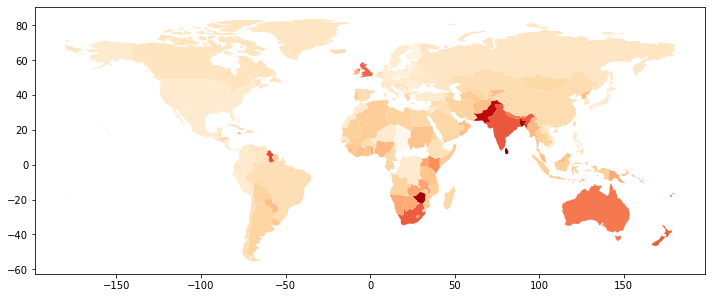

In [38]:
map_term('cricket')